# Required Packages:

- NumPy: For numerical computing
- Matplotlib: For visualizing solution to ODE and its applications
- Jupyter Lab: For running Jupyter notebooks.

All these packages are mentioned in `requirements.txt`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from solver import bvp

# What is BVP?
Boundary value problems (BVP) are a class of problems in which values at boundaries are given, unlike IVPs, where initial value was provided.

# Finite Differences Method:
Finite Differences Method (FDM) is a method to solve ODEs or PDEs numerically, where we need to discretize the equation over an interval with fixed stepsize, and then solving the resulting equations to obtain the solution of ODE or PDE.

Before diving into what was implemented here, I need to state some formulas:
$$\begin{align*}
&\frac{d^2y}{dx^2}=\frac{y_{i+1}-2y_i+y_{i-1}}{h^2}\\
&\frac{dy}{dx}=\frac{y_{i+1}-y_{i-1}}{2h}\\
&\text{In these formulas, we discretized the first and second order differention, which let's us approximate their values in very small intervals.}
\end{align*}$$
We will use these formulas extensively.

## Assumptions:
I have assumed the type of second order ODE to be:
$$
\frac{d^2y}{dx^2}+P(x)\frac{dy}{dx}+Q(x)y=R(x)\qquad y(a)=y_0\text{ and }y(b)=y_N
$$
FDM can be applied equations that do not follow this format, but I have implemented it according to this format.
## Implementation:
$$\begin{align*}
&\text{First we divide our area of interest into }N\text{ parts, with stepsize }h\\
&N=\frac{b-a}{N}\\
&\therefore x_i=a+ih\qquad\forall0\leq i\leq N\\
&x_0=a\text{ and }x_N=b\\
&y_i=y(x_i),\quad P(x_i)=P_i,\quad Q(x_i)=Q_i,\quad R(x_i)=R_i\\
&\text{Using the formulas stated for }y''\text{ and }y'\text{, we will substitute them into the assumed equation:}\\
&\frac{d^2y}{dx^2}+P(x)\frac{dy}{dx}+Q(x)y=R(x)\implies\frac{y_{i+1}-2y_i+y_{i-1}}{h^2}+P_i\left(\frac{y_{i+1}-y_{i-1}}{2h}\right)+Q_iy_i=R_i\\
&\text{Simplifying it we get:}\\
&(2+hP_i)y_{i+1}+(2h^2Q_i-4)y_i+(2-hP_i)y_{i-1}=2h^2R_i\\
&\text{Now, we have }y_0,y_N\text{ but }y_1,y_2,\ldots y_{N-1}\text{ are unknown. So let us start putting }i\text{ such that }0<i<N\\
&(2+hP_1)y_{2}+(2h^2Q_1-4)y_1+(2-hP_1)y_{0}=2h^2R_1\implies(2h^2Q_1-4)y_1+(2+hP_1)y_{2}=2h^2R_1-(2-hP_1)y_{0}\\
&(2+hP_2)y_{3}+(2h^2Q_2-4)y_2+(2-hP_2)y_{1}=2h^2R_2\implies(2-hP_2)y_{1}+(2h^2Q_2-4)y_2+(2+hP_2)y_{3}=2h^2R_2\\
&(2+hP_3)y_{4}+(2h^2Q_3-4)y_3+(2-hP_3)y_{2}=2h^2R_3\implies(2-hP_3)y_{2}+(2h^2Q_3-4)y_3+(2+hP_3)y_{4}=2h^2R_3\\
&\vdots\\
&(2+hP_{N})y_{N}+(2h^2Q_{N-1}-4)y_{N-1}+(2-hP_{N-1})y_{N-2}=2h^2R_{N-1}\implies(2-hP_{N-1})y_{N-2}+(2h^2Q_{N-1}-4)y_{N-1}=2h^2R_{N-1}-(2+hP_{N-1})y_{N}\\
&\text{As we can see, we got ourselves }N-1\text{ linear equation with }N-1\text{ unknowns, that are: }y_1,y_2,y_3,y_4,\ldots,y_{N-1}\\
&\text{Now it leaves realms of Calculus and finds itself in realms of Linear Algebra. We just have to express this in the form of }AX=B\text{ and solve this using any suitable method, like}\\
&\text{LU decomposition, Gaussian elimination or Thomas algorithm.}\\
&\text{Note that every equation has atmost 3 unknowns in it, so if we construct a matrix it would only have elements along a "band" around the diagonal and other entries 0, so we need}\\
&\text{to choose an appropriate algorithm. I have used Thomas algorithm and have never needed to construct the whole }N-1\times N-1\text{ matrix!}
\end{align*}$$
## An example:
Let us try out the method ourselves on a simple second order ODE:
$$
\frac{d^2y}{dx^2}-4y=4x\qquad\text{In }0<x<1\text{ and }y(0)=0, y(1)=2\text{ with stepsize }0.01
$$
Analytically the solution is:
$$
y(x)=Ae^{2x}-Ae^{-2x}-x\qquad\text{Where }A=\frac{3}{e^2-e^{-2}}
$$

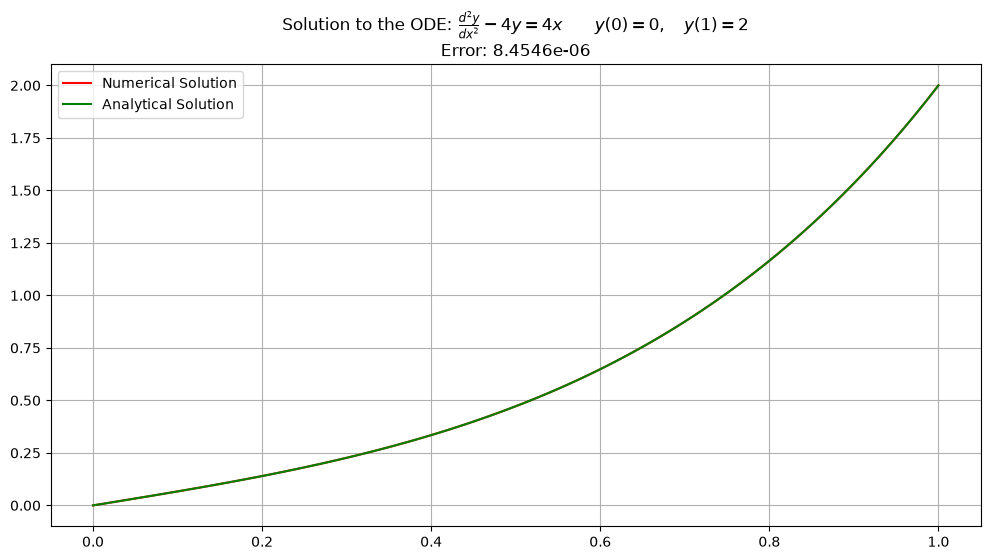

In [2]:
a = 0
b = 1
h = 0.01
p = lambda x: 0*x
q = lambda x: 0*x-4
r = lambda x: 4*x
data = {
    "p": p,
    "q": q,
    "r": r,
    "initial": 0,
    "end": 2
}

A = 3 / (np.exp(2) - np.exp(-2))
sol = lambda x: A*np.exp(2*x)-A*np.exp(-2*x)-x

x, y = bvp.fdm(a, b, h, **data)
plt.figure(figsize=(12, 6))
plt.title("Solution to the ODE: "+r"$\frac{d^2y}{dx^2}-4y=4x\qquad y(0)=0,\quad y(1)=2$"+f"\nError: {np.mean(np.abs(y-sol(x))):.4e}")
plt.plot(x, y, color="red", label="Numerical Solution")
plt.plot(x, sol(x), color="green", label="Analytical Solution")
plt.grid()
plt.legend()
plt.show()